## Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
from torch.utils.tensorboard import SummaryWriter

## Helper Functions

In [2]:
def make_train_step_fn(model, loss_function, optimizer):
    """
    This is a higher order function that returns the function for one train step.
    This will be called inside the training loop.
    Returns loss for that step.
    """
    def perform_train_step_fn(X, y):
        # Set the model to train mode
        model.train()
        # Do one iteration
        y_hat = model(X)
        
        # Calculate loss with the selected loss function
        loss = loss_function(y_hat, y)
        # Calculate gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        # Set gradiants to zero
        optimizer.zero_grad()
        
        # Return loss for this iteration
        return loss.item()
    
    return perform_train_step_fn

In [3]:
def make_val_step_fn(model, loss_function):
    """
    This is a higher order function that returns the function for validation step.
    Returns loss for validation.
    """
    def perform_val_step_fn(X, y):
        # Set the model to eval mode
        model.eval()
        y_hat = model(X)
        
        loss = loss_function(y_hat, y)
        return loss.item()
    
    return perform_val_step_fn

In [4]:
def mini_batch_loop(train_loader, device, train_step_fn):
    batch_losses = []
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        mini_batch_loss = train_step_fn(x_batch, y_batch)
        batch_losses.append(mini_batch_loss)
        
    return np.mean(batch_losses)

## Data Preparation

In [5]:
%run -i data_generation/simple_linear_regression-v2.py

In [6]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


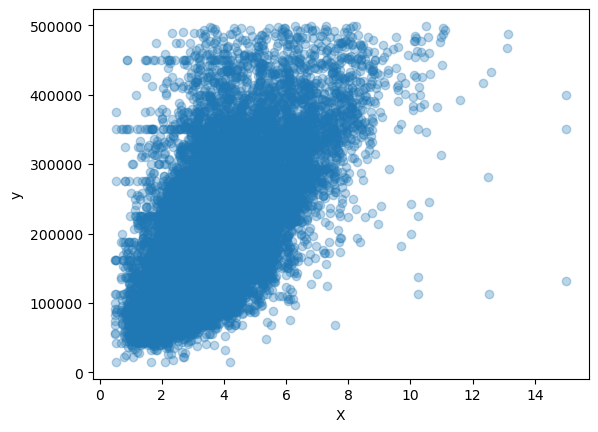

In [7]:
plt.scatter(X, y, alpha=0.3)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [8]:
%run -i data_prepration/v2.py

/home/hananeh/Desktop/DeepLearningStepByStep/data_prepration/v2.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  X_tensor = torch.as_tensor(X).float()


In [9]:
X_tensor.shape, y_tensor.shape

(torch.Size([19648, 1]), torch.Size([19648, 1]))

## Model

In [26]:
# This returns train_step_function with model, optimizer and loss_function
%run -i model_configuration/v3.py

In [27]:
train_step_function

<function __main__.make_train_step_fn.<locals>.perform_train_step_fn(X, y)>

In [28]:
val_step_function

<function __main__.make_val_step_fn.<locals>.perform_val_step_fn(X, y)>

## Training

In [29]:
%run -i model_training/v5.py

epoch 0/1000
epoch 100/1000
epoch 200/1000
epoch 300/1000
epoch 400/1000
epoch 500/1000
epoch 600/1000
epoch 700/1000
epoch 800/1000
epoch 900/1000


In [19]:
writer = SummaryWriter('runs/test')

dummy_x, dummy_y = next(iter(train_loader))
writer.add_graph(model, dummy_x.to(device))

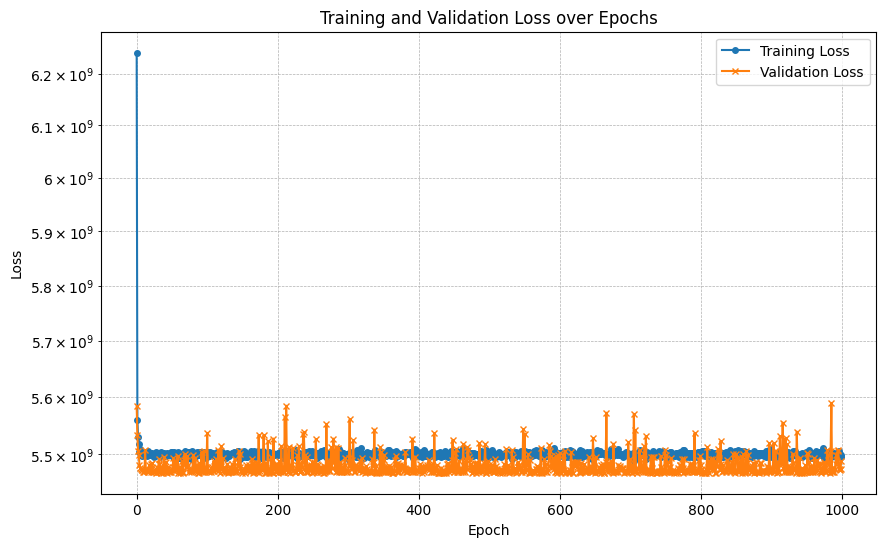

In [14]:
plt.figure(figsize=(10,6))

plt.plot(losses, label='Training Loss', marker='o', markersize=4)

plt.plot(val_losses, label='Validation Loss', marker='x', markersize=4)

# Optional: logarithmic scale if values are very large
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [21]:
print(model.state_dict())

OrderedDict({'0.weight': tensor([[41285.7422]]), '0.bias': tensor([44284.0078])})


In [22]:
all_preds = []
all_inputs = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        
        all_preds.append(outputs.cpu())
        all_inputs.append(inputs.cpu())

# Concatenate all batches into a single tensor
all_preds = torch.cat(all_preds)
all_inputs = torch.cat(all_inputs)

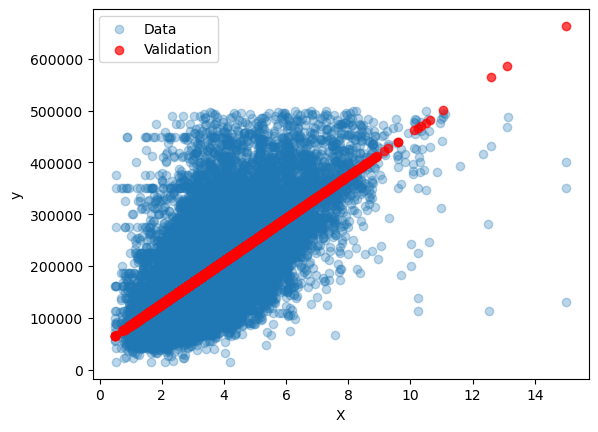

In [23]:
plt.scatter(X, y, alpha=0.3, label="Data")
plt.scatter(all_inputs, all_preds, alpha=0.7, color="red", label="Validation")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [31]:
checkpoint = {
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': losses,
    'val_loss': val_losses,
}

torch.save(checkpoint, 'model_checkpoint.pth')